In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from prophet import Prophet
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

In [ ]:
df_test=pd.read_csv("/content/drive/MyDrive/Facebook Prophet/DailyDelhiClimateTest.csv")
df_train=pd.read_csv("/content/drive/MyDrive/Facebook Prophet/DailyDelhiClimateTrain.csv")
df=df_train
df_train

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...,...
1457,2016-12-28,17.217391,68.043478,3.547826,1015.565217
1458,2016-12-29,15.238095,87.857143,6.000000,1016.904762
1459,2016-12-30,14.095238,89.666667,6.266667,1017.904762
1460,2016-12-31,15.052632,87.000000,7.325000,1016.100000


In [ ]:
len(df_test)

114

In [ ]:
len(df_train)

1462

In [ ]:
df_test

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333
...,...,...,...,...,...
109,2017-04-20,34.500000,27.500000,5.562500,998.625000
110,2017-04-21,34.250000,39.375000,6.962500,999.875000
111,2017-04-22,32.900000,40.900000,8.890000,1001.600000
112,2017-04-23,32.875000,27.500000,9.962500,1002.125000


In [ ]:
df_train.head(5)

,ds,y,humidity,wind_speed,meanpressure,y_orig
0,2013-01-01,2.302585,84.500000,0.000000,1015.666667,10.000000
1,2013-01-02,2.001480,92.000000,2.980000,1017.800000,7.400000
2,2013-01-03,1.969441,87.000000,4.633333,1018.666667,7.166667
3,2013-01-04,2.159484,71.333333,1.233333,1017.166667,8.666667
4,2013-01-05,1.791759,86.833333,3.700000,1016.500000,6.000000


# Uni-Variate Forecasting

In [ ]:
df_train = df_train.rename(columns={'meantemp': 'y', 'date':'ds'})
df_train['y_orig'] = df_train['y'] # to save a copy of the original data..you'll see why shortly.
df_train['y'] = np.log(df_train['y'])


In [ ]:
df_train.head(5)

,ds,y,humidity,wind_speed,meanpressure,y_orig
0,2013-01-01,2.302585,84.500000,0.000000,1015.666667,10.000000
1,2013-01-02,2.001480,92.000000,2.980000,1017.800000,7.400000
2,2013-01-03,1.969441,87.000000,4.633333,1018.666667,7.166667
3,2013-01-04,2.159484,71.333333,1.233333,1017.166667,8.666667
4,2013-01-05,1.791759,86.833333,3.700000,1016.500000,6.000000


In [ ]:
model = Prophet() #instantiate Prophet
model.fit(df_train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7o4pboqu/a7r6l9cb.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7o4pboqu/ercxzd4f.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=80634', 'data', 'file=/tmp/tmp7o4pboqu/a7r6l9cb.json', 'init=/tmp/tmp7o4pboqu/ercxzd4f.json', 'output', 'file=/tmp/tmp7o4pboqu/prophet_modeldyxm9iwq/prophet_model-20230731114724.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:47:24 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:47:24 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
''' 'year': 'A',
        'quarter': 'Q',
        'month': 'M',
        'day': 'D',
        'hour': 'H',
        'minute': 'T',
        'second': 'S',
        'millisecond': 'L',
        'microsecond': 'U',
        'nanosecond': 'N'}
'''


future_data = model.make_future_dataframe(periods=113, freq = 'D')

forecast_data = model.predict(future_data)

forecast_data[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5)

,ds,yhat,yhat_lower,yhat_upper
1570,2017-04-20,3.553332,3.427867,3.678536
1571,2017-04-21,3.557127,3.433237,3.674836
1572,2017-04-22,3.557428,3.432993,3.686443
1573,2017-04-23,3.556817,3.437448,3.678492
1574,2017-04-24,3.574090,3.445740,3.690023


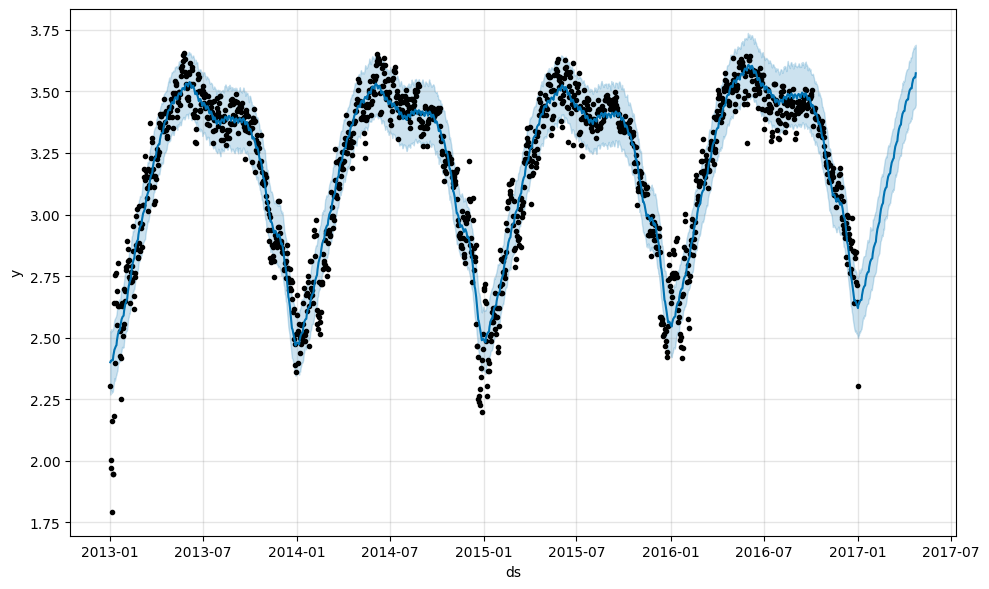

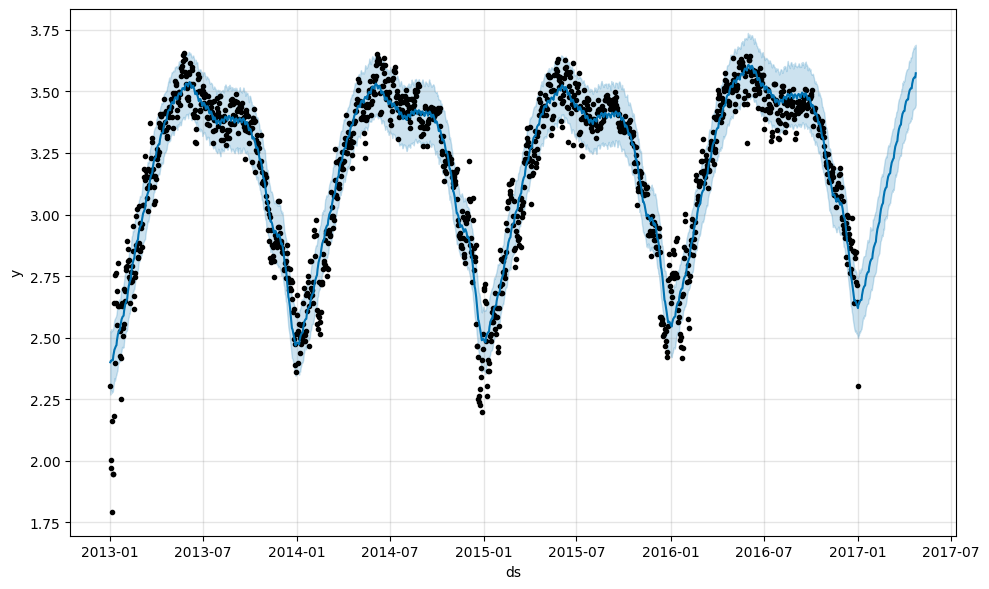

In [ ]:
model.plot(forecast_data)

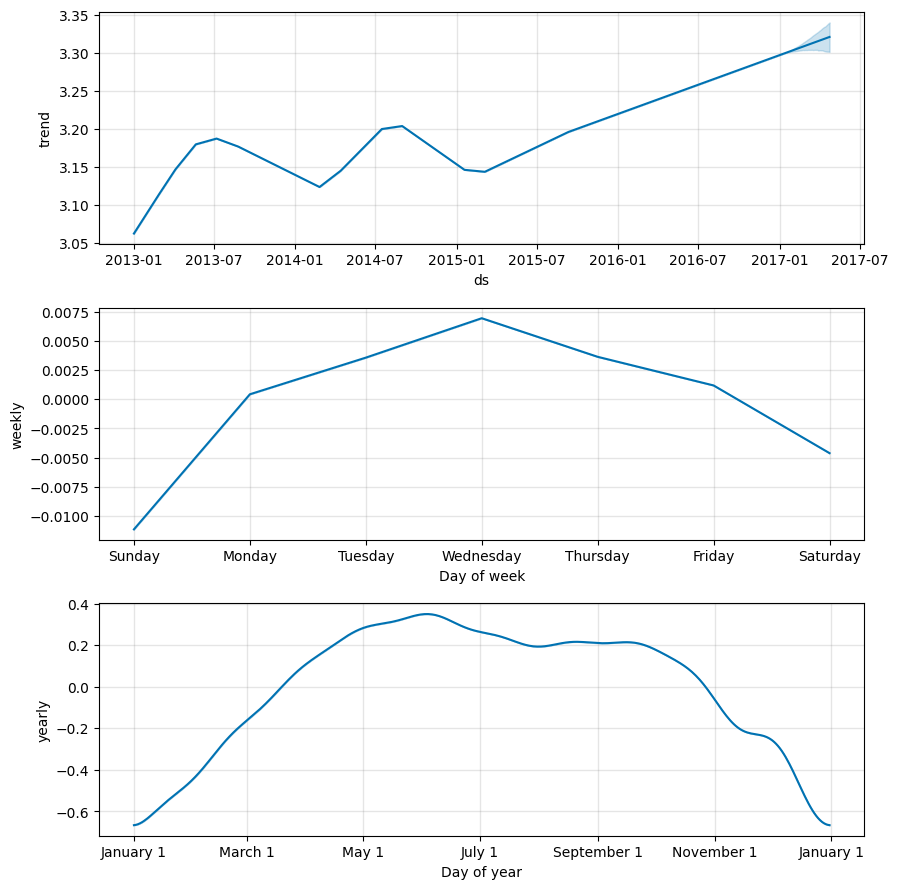

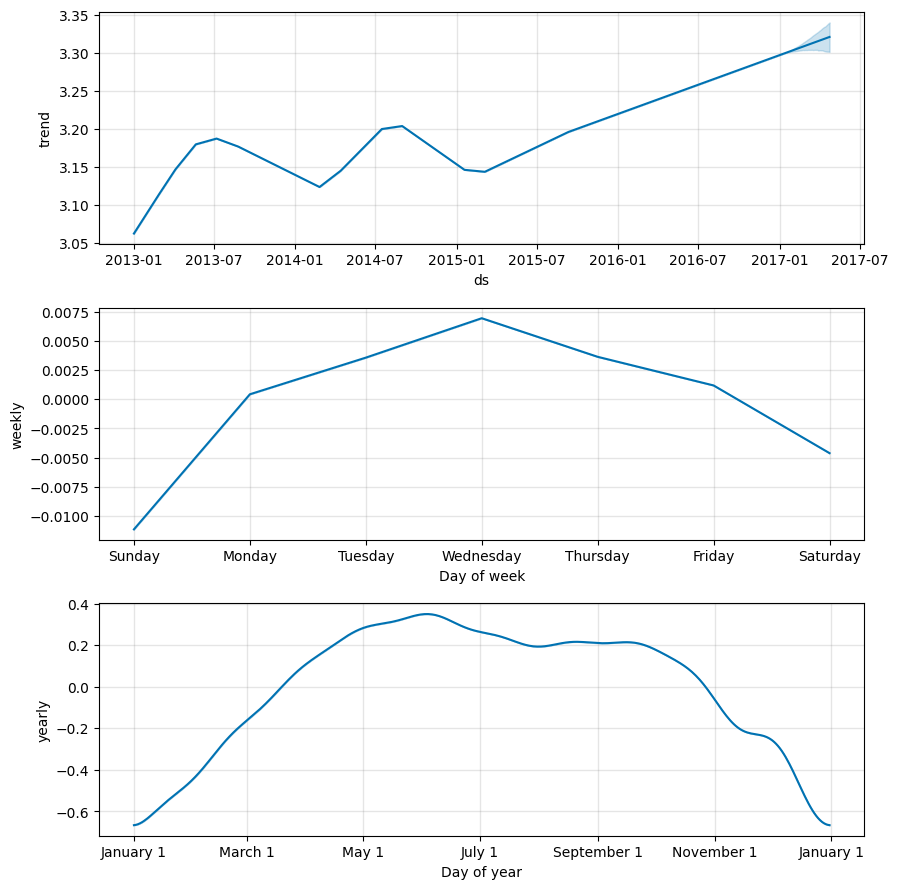

In [ ]:
model.plot_components(forecast_data)

In [ ]:
forecast_data_orig = forecast_data # make sure we save the original forecast data
forecast_data_orig['yhat'] = np.exp(forecast_data_orig['yhat'])
forecast_data_orig['yhat_lower'] = np.exp(forecast_data_orig['yhat_lower'])
forecast_data_orig['yhat_upper'] = np.exp(forecast_data_orig['yhat_upper'])

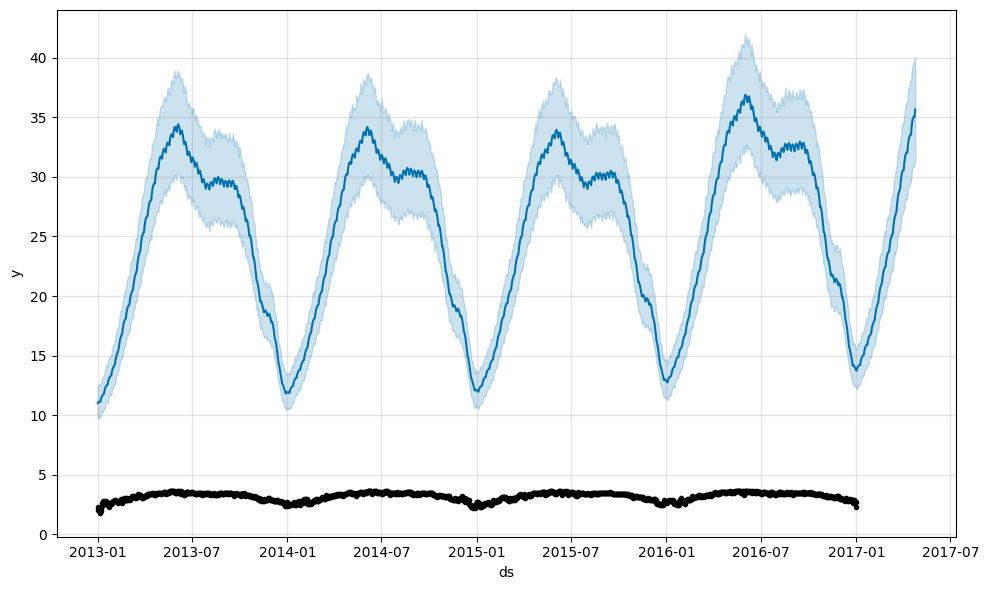

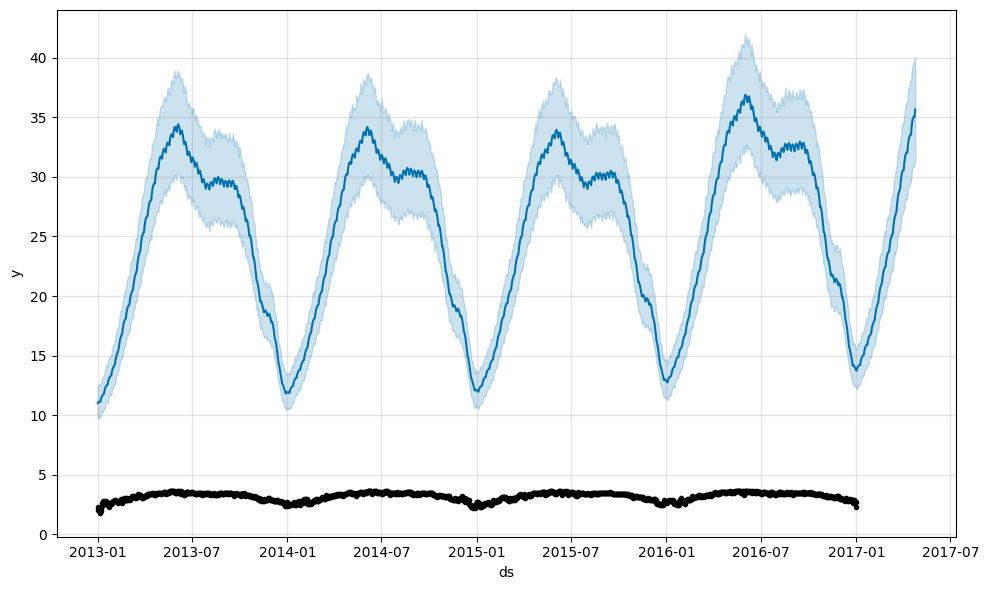

In [ ]:
model.plot(forecast_data_orig)

In [ ]:
df_train['y_log']=df_train['y'] #copy the log-transformed data to another column
df_train['y']=df_train['y_orig']

In [ ]:
final_df = pd.DataFrame(forecast_data_orig)
import plotly.graph_objs as go
import plotly.offline as py
#Plot predicted and actual line graph with X=dates, Y=Outbound
actual_chart = go.Scatter(y=df_train["y_orig"], name= 'Actual')
predict_chart = go.Scatter(y=final_df["yhat"], name= 'Predicted')
predict_chart_upper = go.Scatter(y=final_df["yhat_upper"], name= 'Predicted Upper')
predict_chart_lower = go.Scatter(y=final_df["yhat_lower"], name= 'Predicted Lower')
py.plot([actual_chart, predict_chart, predict_chart_upper, predict_chart_lower])

'temp-plot.html'

In [ ]:
df_test.head(5)

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [ ]:
final_df.tail(113)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1462,2017-01-02,3.297240,12.256667,15.611002,3.297240,3.297240,-0.664501,-0.664501,-0.664501,0.000427,0.000427,0.000427,-0.664928,-0.664928,-0.664928,0.0,0.0,0.0,13.911823
1463,2017-01-03,3.297451,12.306259,15.837502,3.297451,3.297451,-0.658632,-0.658632,-0.658632,0.003566,0.003566,0.003566,-0.662198,-0.662198,-0.662198,0.0,0.0,0.0,13.996662
1464,2017-01-04,3.297663,12.490345,16.059339,3.297663,3.297663,-0.651395,-0.651395,-0.651395,0.006942,0.006942,0.006942,-0.658337,-0.658337,-0.658337,0.0,0.0,0.0,14.101311
1465,2017-01-05,3.297875,12.439575,15.852442,3.297875,3.297875,-0.649835,-0.649835,-0.649835,0.003636,0.003636,0.003636,-0.653471,-0.653471,-0.653471,0.0,0.0,0.0,14.126323
1466,2017-01-06,3.298086,12.512605,15.935641,3.298086,3.298086,-0.646548,-0.646548,-0.646548,0.001184,0.001184,0.001184,-0.647732,-0.647732,-0.647732,0.0,0.0,0.0,14.175830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1570,2017-04-20,3.320096,30.810850,39.588393,3.301587,3.337935,0.233236,0.233236,0.233236,0.003636,0.003636,0.003636,0.229600,0.229600,0.229600,0.0,0.0,0.0,34.929524
1571,2017-04-21,3.320308,30.976759,39.442180,3.301601,3.338423,0.236819,0.236819,0.236819,0.001184,0.001184,0.001184,0.235635,0.235635,0.235635,0.0,0.0,0.0,35.062306
1572,2017-04-22,3.320519,30.969180,39.902656,3.301497,3.339142,0.236908,0.236908,0.236908,-0.004614,-0.004614,-0.004614,0.241522,0.241522,0.241522,0.0,0.0,0.0,35.072856
1573,2017-04-23,3.320731,31.107468,39.586643,3.301426,3.339431,0.236086,0.236086,0.236086,-0.011141,-0.011141,-0.011141,0.247227,0.247227,0.247227,0.0,0.0,0.0,35.051465


In [ ]:
rows = final_df["yhat"].tail(113)

In [ ]:
rows = rows.reset_index()

In [ ]:
rows.pop('index')

0      1462
1      1463
2      1464
3      1465
4      1466
       ... 
108    1570
109    1571
110    1572
111    1573
112    1574
Name: index, Length: 113, dtype: int64

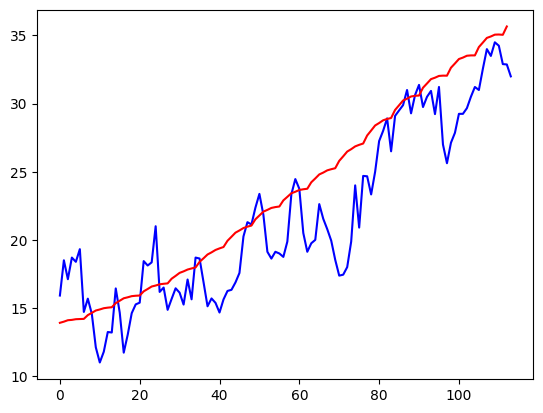

In [ ]:
# plot

import matplotlib.pyplot as plt
plt.plot(df_test['meantemp'], color = 'blue')
plt.plot(rows, color='red')
plt.show()

# Multi-Variate Forecasting

In [ ]:
df_test=pd.read_csv("/content/drive/MyDrive/Facebook Prophet/DailyDelhiClimateTest.csv")
df_train=pd.read_csv("/content/drive/MyDrive/Facebook Prophet/DailyDelhiClimateTrain.csv")
df=df_train
df_train

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...,...
1457,2016-12-28,17.217391,68.043478,3.547826,1015.565217
1458,2016-12-29,15.238095,87.857143,6.000000,1016.904762
1459,2016-12-30,14.095238,89.666667,6.266667,1017.904762
1460,2016-12-31,15.052632,87.000000,7.325000,1016.100000


In [ ]:
df_train = df_train.rename(columns={'meantemp': 'y', 'date':'ds'})
df_train['y_orig'] = df_train['y'] # to save a copy of the original data..you'll see why shortly.
df_train['y'] = np.log(df_train['y'])

In [ ]:
df_train.head(5)

,ds,y,humidity,wind_speed,meanpressure,y_orig
0,2013-01-01,2.302585,84.500000,0.000000,1015.666667,10.000000
1,2013-01-02,2.001480,92.000000,2.980000,1017.800000,7.400000
2,2013-01-03,1.969441,87.000000,4.633333,1018.666667,7.166667
3,2013-01-04,2.159484,71.333333,1.233333,1017.166667,8.666667
4,2013-01-05,1.791759,86.833333,3.700000,1016.500000,6.000000


In [ ]:


model_new = Prophet() #instantiate Prophet
model_new.add_regressor('humidity')
model_new.add_regressor('wind_speed')
model_new.add_regressor('meanpressure')

In [ ]:


model_new.fit(df_train)

''' 'year': 'A',
        'quarter': 'Q',
        'month': 'M',
        'day': 'D',
        'hour': 'H',
        'minute': 'T',
        'second': 'S',
        'millisecond': 'L',
        'microsecond': 'U',
        'nanosecond': 'N'}
'''

#future_data = model.make_future_dataframe(periods=6, freq = 'H')
future_data = model_new.make_future_dataframe(periods=113, freq = 'D')

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7o4pboqu/f5ymvb29.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7o4pboqu/palil4f9.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=67761', 'data', 'file=/tmp/tmp7o4pboqu/f5ymvb29.json', 'init=/tmp/tmp7o4pboqu/palil4f9.json', 'output', 'file=/tmp/tmp7o4pboqu/prophet_modelb7rvx0su/prophet_model-20230731115409.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:54:09 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:54:10 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
future_data.head(5)

,ds
0,2013-01-01
1,2013-01-02
2,2013-01-03
3,2013-01-04
4,2013-01-05


In [ ]:
df=df.append(df_test)
df = df.rename(columns={'meantemp': 'y', 'date':'ds'})
future_data=df[['ds', 'humidity', 'wind_speed', 'meanpressure']]

<ipython-input-33-b7ed24a60f31>:1: FutureWarning:

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



In [ ]:
future_data.head(5)

,ds,humidity,wind_speed,meanpressure
0,2013-01-01,84.500000,0.000000,1015.666667
1,2013-01-02,92.000000,2.980000,1017.800000
2,2013-01-03,87.000000,4.633333,1018.666667
3,2013-01-04,71.333333,1.233333,1017.166667
4,2013-01-05,86.833333,3.700000,1016.500000


In [ ]:
forecast_data = model_new.predict(future_data)

forecast_data[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5)

,ds,yhat,yhat_lower,yhat_upper
1571,2017-04-20,3.574815,3.465359,3.688067
1572,2017-04-21,3.523552,3.416495,3.642395
1573,2017-04-22,3.519486,3.408584,3.629732
1574,2017-04-23,3.578725,3.463852,3.682704
1575,2017-04-24,3.589640,3.476274,3.693182


In [ ]:
forecast_data

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,extra_regressors_additive,...,wind_speed,wind_speed_lower,wind_speed_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-01,3.037172,2.243416,2.464475,3.037172,3.037172,-0.686254,-0.686254,-0.686254,-0.102164,...,0.009582,0.009582,0.009582,-0.586768,-0.586768,-0.586768,0.0,0.0,0.0,2.350919
1,2013-01-02,3.038292,2.206678,2.430320,3.038292,3.038292,-0.721561,-0.721561,-0.721561,-0.141688,...,0.005384,0.005384,0.005384,-0.583552,-0.583552,-0.583552,0.0,0.0,0.0,2.316731
2,2013-01-03,3.039412,2.233179,2.449145,3.039412,3.039412,-0.700977,-0.700977,-0.700977,-0.120484,...,0.003055,0.003055,0.003055,-0.579066,-0.579066,-0.579066,0.0,0.0,0.0,2.338436
3,2013-01-04,3.040533,2.320688,2.536012,3.040533,3.040533,-0.615100,-0.615100,-0.615100,-0.041927,...,0.007844,0.007844,0.007844,-0.573457,-0.573457,-0.573457,0.0,0.0,0.0,2.425433
4,2013-01-05,3.041653,2.250744,2.463686,3.041653,3.041653,-0.684245,-0.684245,-0.684245,-0.118368,...,0.004370,0.004370,0.004370,-0.566885,-0.566885,-0.566885,0.0,0.0,0.0,2.357407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571,2017-04-20,3.309400,3.465359,3.688067,3.291530,3.327278,0.265415,0.265415,0.265415,0.158484,...,0.001746,0.001746,0.001746,0.108357,0.108357,0.108357,0.0,0.0,0.0,3.574815
1572,2017-04-21,3.309601,3.416495,3.642395,3.291409,3.327813,0.213951,0.213951,0.213951,0.100596,...,-0.000226,-0.000226,-0.000226,0.113071,0.113071,0.113071,0.0,0.0,0.0,3.523552
1573,2017-04-22,3.309802,3.408584,3.629732,3.291214,3.328331,0.209684,0.209684,0.209684,0.090688,...,-0.002941,-0.002941,-0.002941,0.117989,0.117989,0.117989,0.0,0.0,0.0,3.519486
1574,2017-04-23,3.310003,3.463852,3.682704,3.291012,3.328782,0.268722,0.268722,0.268722,0.152259,...,-0.004452,-0.004452,-0.004452,0.123060,0.123060,0.123060,0.0,0.0,0.0,3.578725


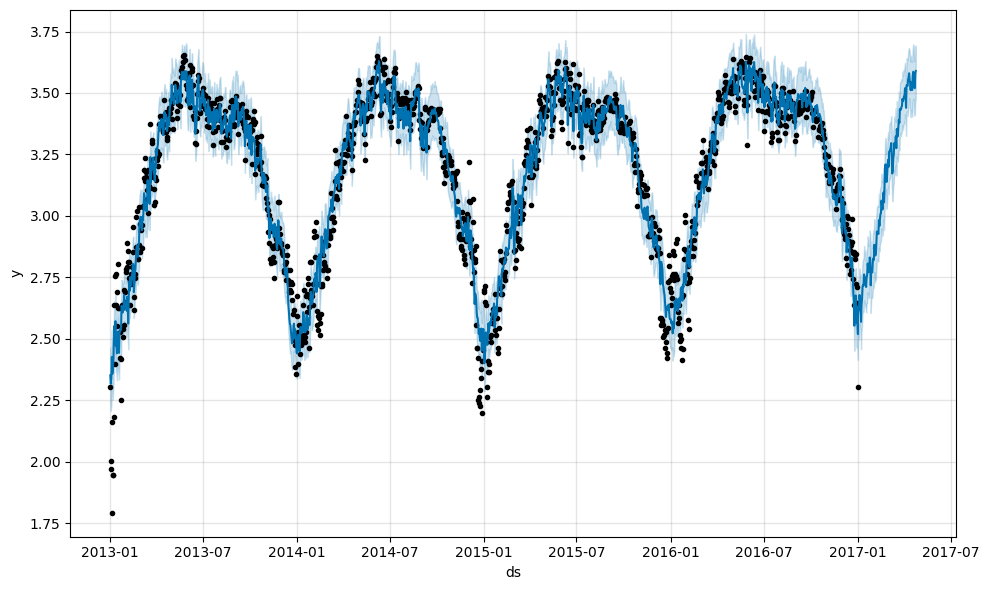

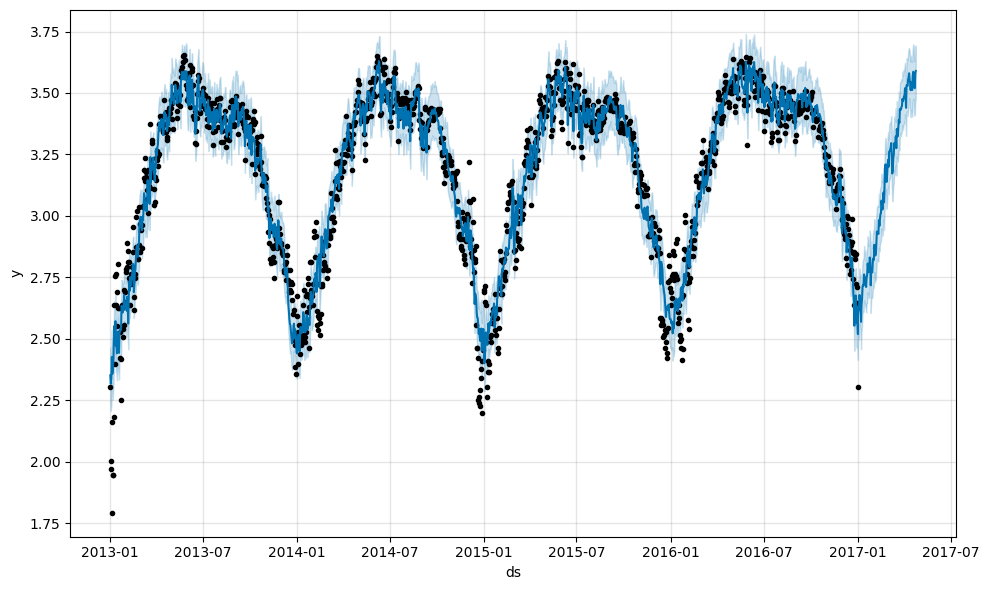

In [ ]:
model_new.plot(forecast_data)

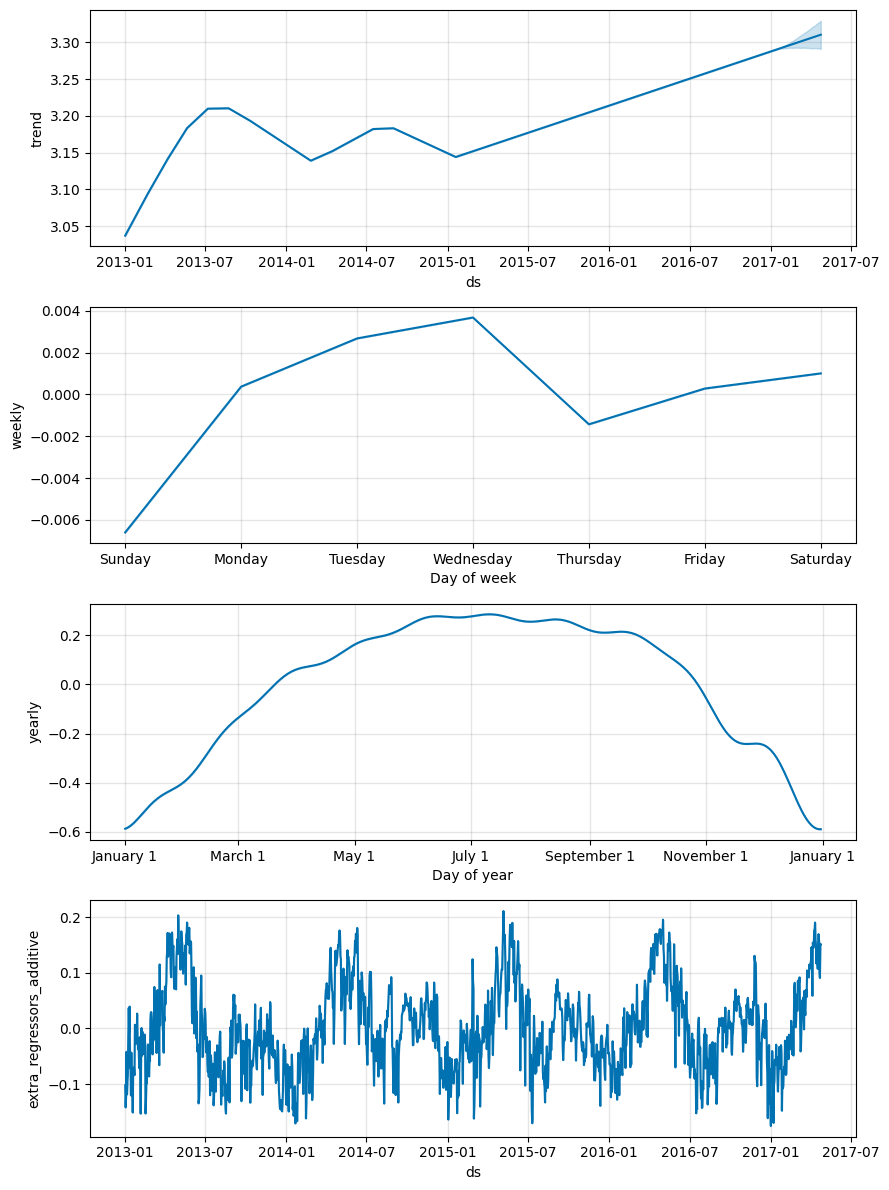

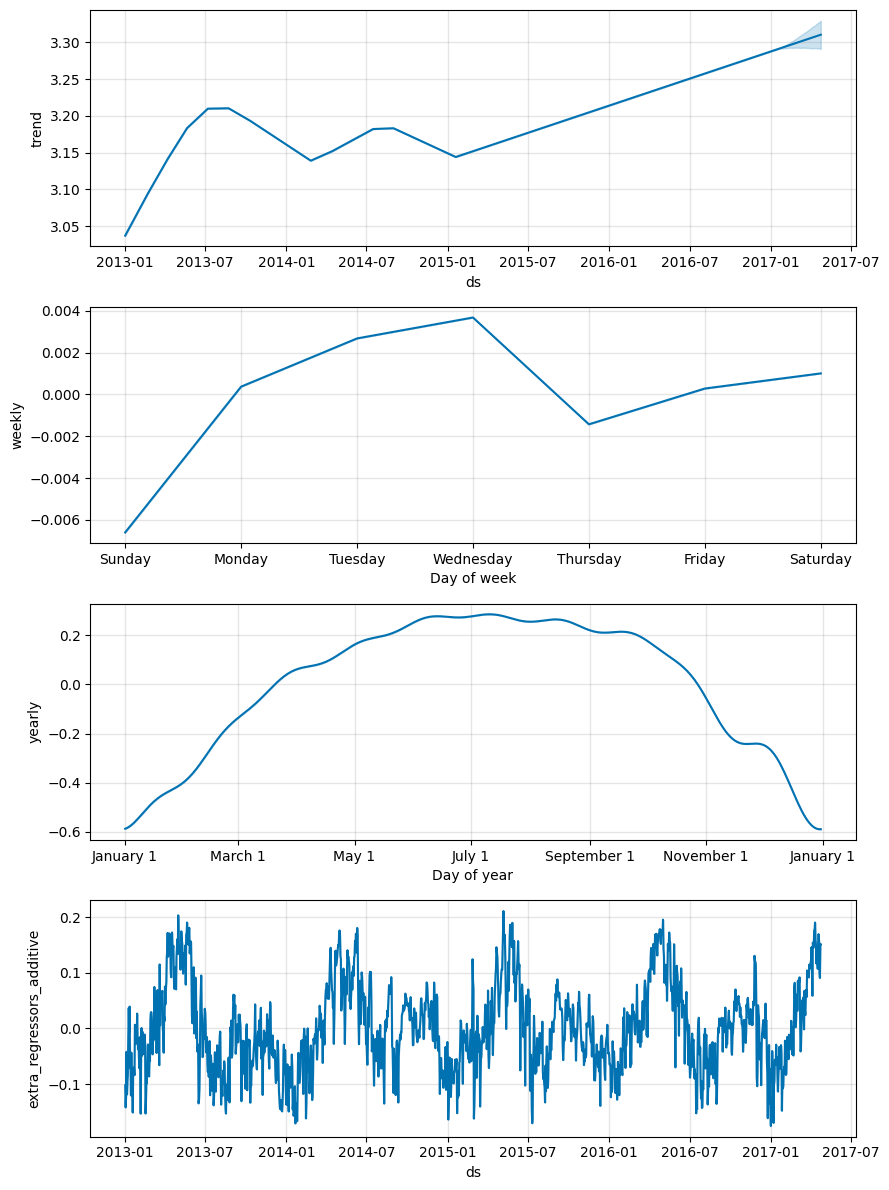

In [ ]:
model_new.plot_components(forecast_data)

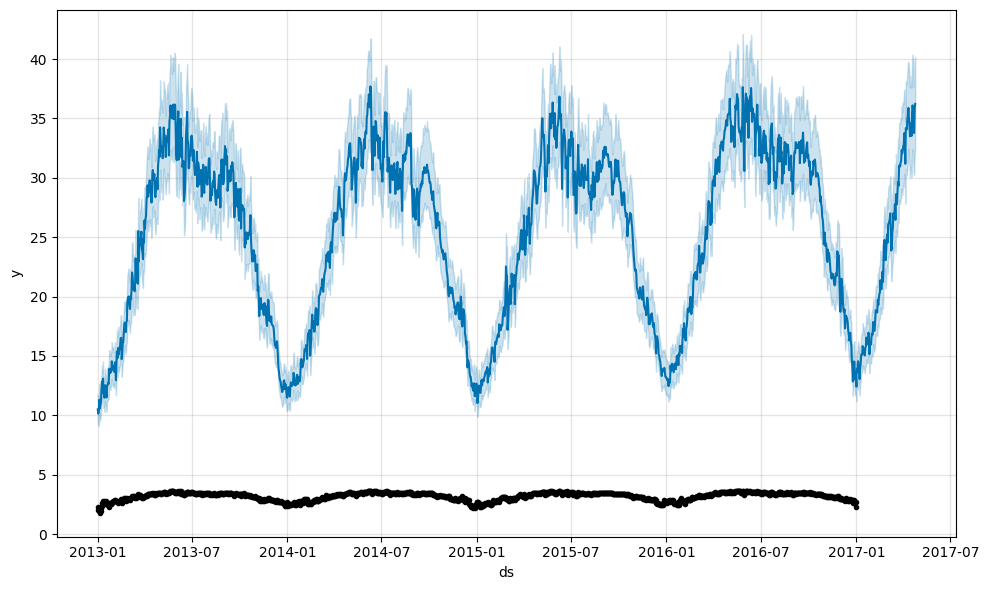

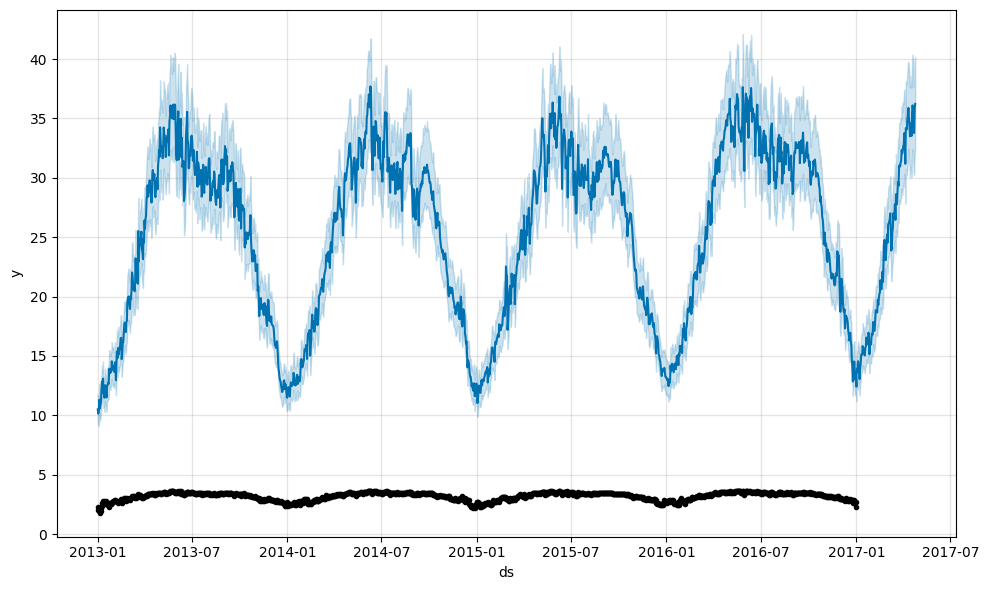

In [ ]:
forecast_data_orig = forecast_data # make sure we save the original forecast data
forecast_data_orig['yhat'] = np.exp(forecast_data_orig['yhat'])
forecast_data_orig['yhat_lower'] = np.exp(forecast_data_orig['yhat_lower'])
forecast_data_orig['yhat_upper'] = np.exp(forecast_data_orig['yhat_upper'])

model_new.plot(forecast_data_orig)

In [ ]:
df_train['y_log']=df_train['y'] #copy the log-transformed data to another column
df_train['y']=df_train['y_orig']

In [ ]:
final_df = pd.DataFrame(forecast_data_orig)
import plotly.graph_objs as go
import plotly.offline as py
#Plot predicted and actual line graph with X=dates, Y=Outbound
actual_chart = go.Scatter(y=df_train["y_orig"], name= 'Actual')
predict_chart = go.Scatter(y=final_df["yhat"], name= 'Predicted')
predict_chart_upper = go.Scatter(y=final_df["yhat_upper"], name= 'Predicted Upper')
predict_chart_lower = go.Scatter(y=final_df["yhat_lower"], name= 'Predicted Lower')
py.plot([actual_chart, predict_chart, predict_chart_upper, predict_chart_lower])

'temp-plot.html'